In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
keras.utils.set_random_seed(42)



In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [7]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


In [8]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [9]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]



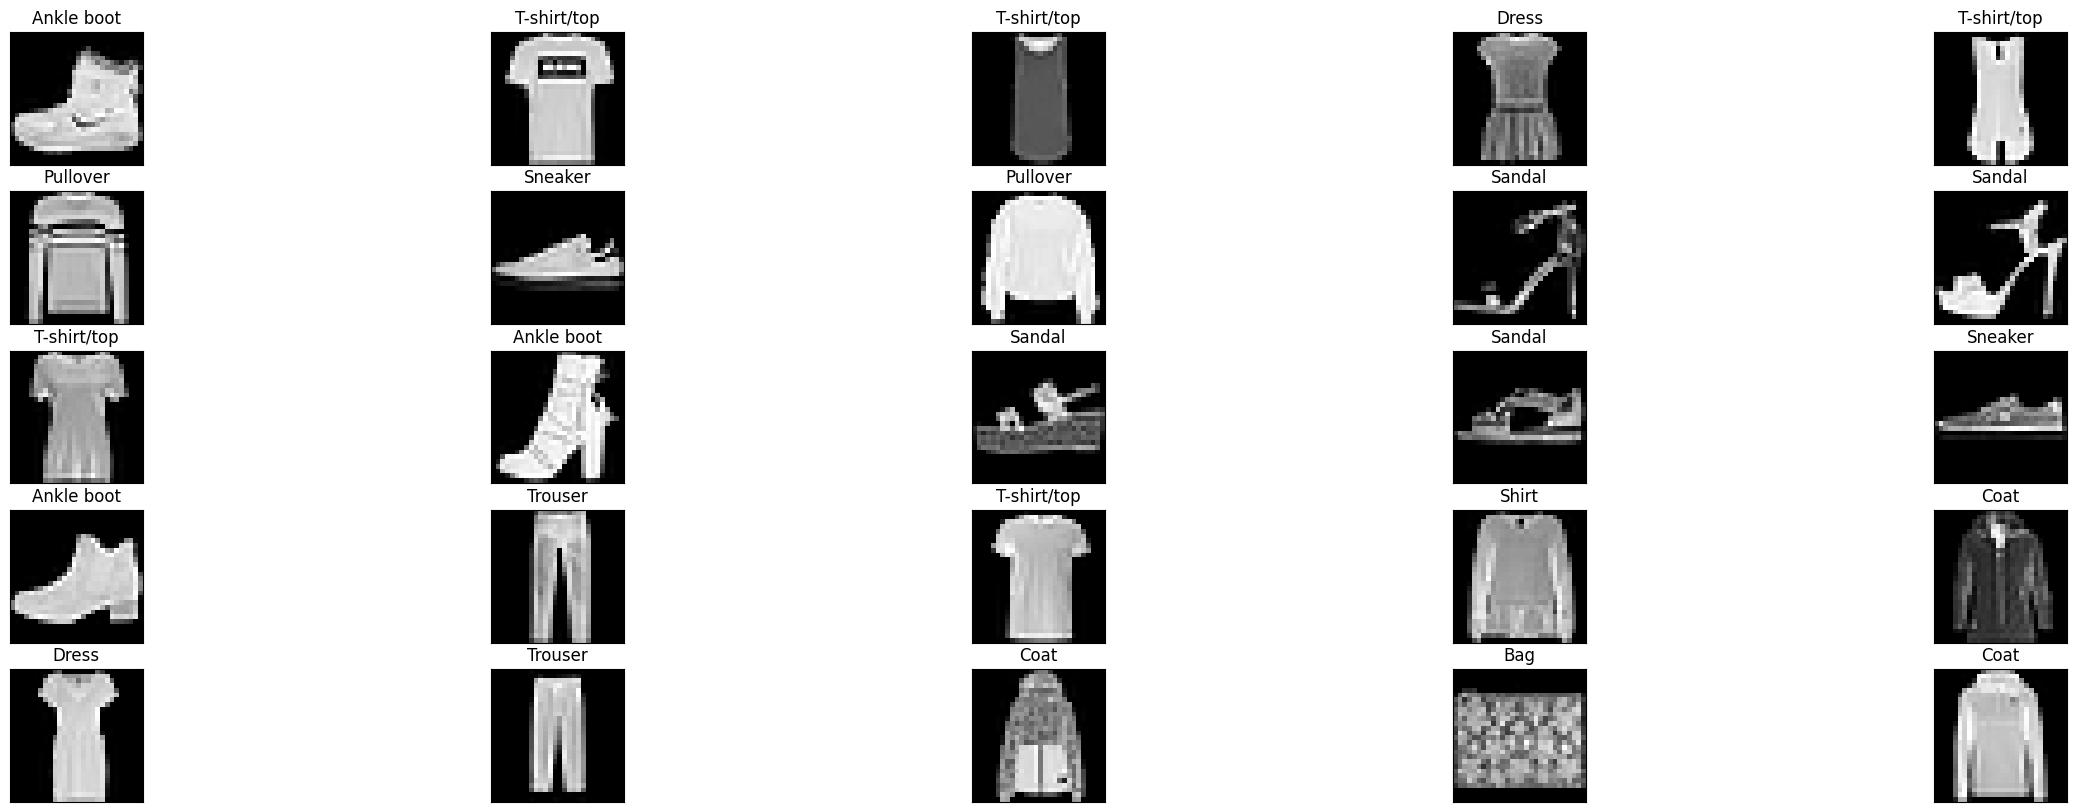

In [10]:
fig, ax = plt.subplots(5, 5, figsize=(30, 10))
for i in range(25):
  axc = ax[i//5, i%5]
  axc.imshow(x_train[i], cmap="gray")
  axc.set_title(f"{labels[y_train[i]]}")
  axc.set_xticks([])
  axc.set_yticks([])

In [11]:
data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
])
input = keras.Input(shape=(28, 28, 1))
x = data_augmentation(input)
x = keras.layers.Conv2D(32, (3, 3), activation="gelu")(input)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(64, (3, 3), activation="gelu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(128, activation="gelu")(x)
x = keras.layers.Dropout(0.5)(x)
output3 = keras.layers.Dense(10, activation="softmax")(x)
model = keras.Model(input, output3)


In [12]:
optimizer = keras.optimizers.Adam(learning_rate=2e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])


In [13]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)

batch_size = 32
epochs = 20
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(x_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping],
                    )


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6115 - loss: 1.3871 - val_accuracy: 0.7741 - val_loss: 0.5909
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7411 - loss: 0.7174 - val_accuracy: 0.8202 - val_loss: 0.4854
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7892 - loss: 0.5765 - val_accuracy: 0.8501 - val_loss: 0.4130
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8176 - loss: 0.4966 - val_accuracy: 0.8633 - val_loss: 0.3783
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8362 - loss: 0.4489 - val_accuracy: 0.8772 - val_loss: 0.3457
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8533 - loss: 0.4025 - val_accuracy: 0.8819 - val_loss: 0.3277
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8661 - loss: 0.3694 - val_accuracy: 0.8868 - val_loss: 0.3111
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8730 - loss: 0.3446 -

In [14]:
def plot_loss_curves(history, modelName):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title(f"{modelName} Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [15]:
def plot_acc_curves(history, modelName):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title(f"{modelName} Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

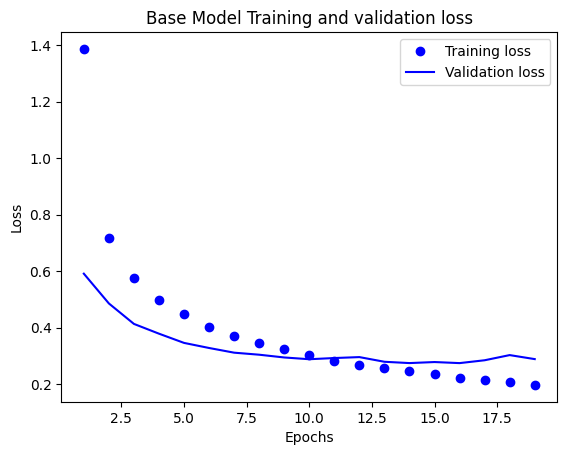

In [16]:
plot_loss_curves(history, "Base Model")

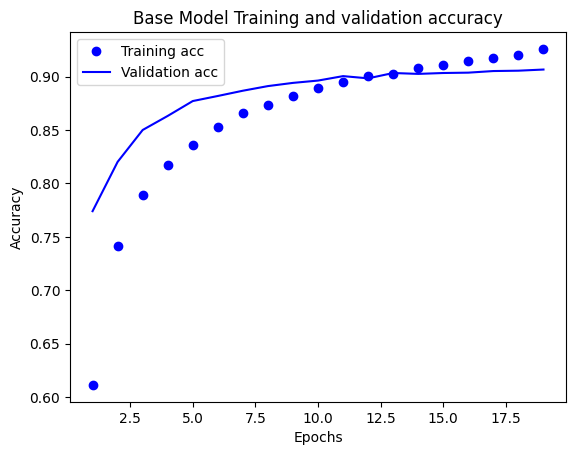

In [17]:
plot_acc_curves(history, "Base Model")


In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8995 - loss: 0.2929
Test Accuracy: 0.8995
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


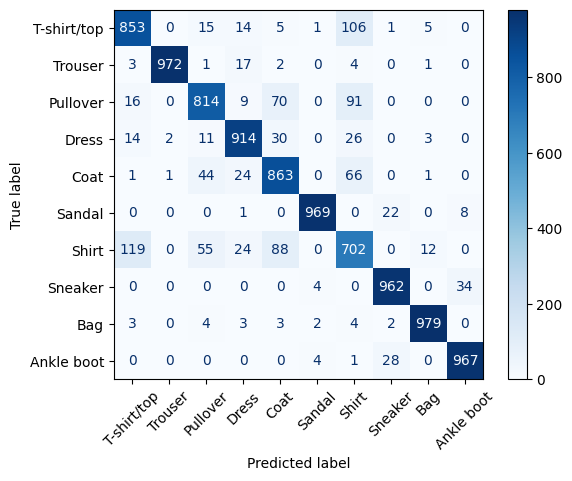

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true_classes = np.argmax(y_test, axis=1)
else:
    y_true_classes = y_test

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()

# answers

### #1
  I used simple rotational and transaltion data augmentation to artificially grow the dataset to improve the traning process.
### #2
for my classifier I went with a 3 layer design using conv2d layers with max pooling and a dropout, this leads to a total parameter count of 675k. I chose to use GELU as my activation function as it is smooth and doesn't have the dead neuron issues of RELU. I chose this architecture as it is the one that I know.

### #3
for my training I used the adam optimizer which I found worked better than adamW. I used sparse_categorical_crossentropy as the loss function and accuracy as the metrics. I ran for 20 epochs(with early stopping so it usally didn't get that far) and a batch size of 32.

### #4
The model clearly learned quite well and the performance did improve greatly.
Overfitting was not seen very much as I had early stopping enabled to prevent it with a patience of 3. However it did trigger most runs meaning that had it continued to run it would become overfit. Both training and validation trended together which is a decent sign of succsess.

### #5
The final accuracy was 90% I tried to push higher by adjusting a few hyperparameters but couldn't break that barier the final test loss was 0.29. This shows that it is a decently accurate predictor.

##6
See confustion matrix above.

The model did very well identifying sandals and trouser but struggled to differentiate shirts and t-shirt/top classes, this makes sense as the ones it did best are very distinct but the distinction between the classes it struggled on is much less.



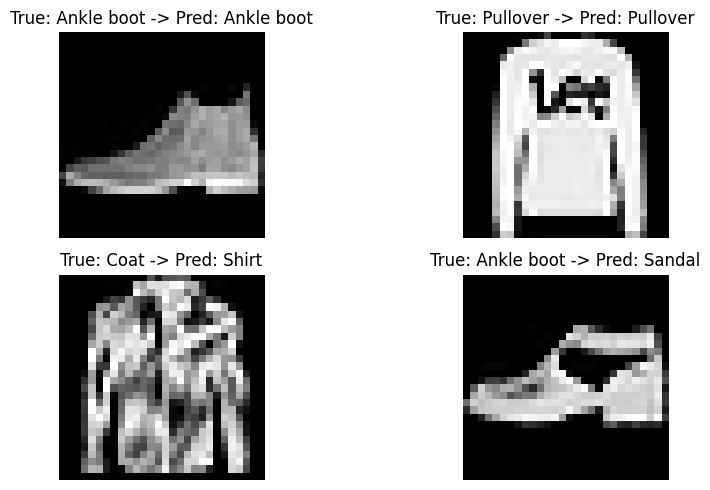

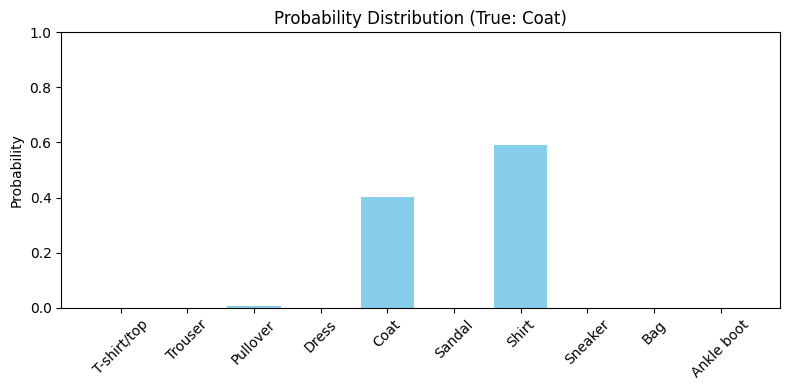

In [20]:
import numpy as np
import matplotlib.pyplot as plt

correct_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

sample_correct = correct_indices[:2]
sample_incorrect = incorrect_indices[:2]
selected_indices = np.concatenate([sample_correct, sample_incorrect])

plt.figure(figsize=(10, 5))
for i, idx in enumerate(selected_indices):
    plt.subplot(2, 2, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    actual_label = labels[y_true_classes[idx]]
    pred_label = labels[y_pred_classes[idx]]
    plt.title(f"True: {actual_label} -> Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

target_idx = incorrect_indices[0] if len(incorrect_indices) > 0 else correct_indices[0]
probabilities = y_pred[target_idx]

plt.figure(figsize=(8, 4))
plt.bar(range(10), probabilities, color="skyblue")
plt.xticks(range(10), labels, rotation=45)
plt.ylabel("Probability")
plt.title(f"Probability Distribution (True: {labels[y_true_classes[target_idx]]})")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

For the classification task, a 3-layer convolutional neural network was implemented using Conv2D layers with max pooling and dropout, resulting in a total parameter count of 675k with GELU activation functions. This architecture was chosen primarily because it was the one most familiar to work with, and the dataset was artificially expanded using simple rotational and translation data augmentation. Trained using the Adam optimizer, sparse categorical crossentropy loss, a batch size of 32, and early stopping with a patience of 3, training and validation performance tracked closely together. While early stopping frequently triggered near the end of runs to prevent divergence, significant overfitting was avoided.

The model achieved a final test accuracy of 90% alongside a test loss of 0.29, demonstrating solid predictive performance. An evaluation of the confusion matrix revealed that distinct items like sandals and trousers were identified very well, whereas the model struggled most to differentiate between visually similar classes such as shirts and t-shirt/tops. A few challanges that I faced during this was in trying to push the accuracy above 90% which I never ended up succseeding in. If I were to repeat this to attempt to get better accuracy I would probably try harder in the areas of learning rate scheduleing and maybe even better data augmentation.